In [120]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Import Libraries

In [121]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

# Loading the Dataset

The training, test, and sample submission files are loaded from the Kaggle input directory. Keeping these datasets separate establishes a structured workflow for model training, evaluation, and final submission generation.

In [122]:
train = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
)


sample = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"
)

# Dataset Shape


## Findings

- The training dataset contains **2,000 samples** with **8 columns**, providing sufficient data for model training.
- The test dataset consists of **500 samples** with **7 columns**, which will be used for generating predictions.
- The training dataset has one additional column compared to the test dataset, indicating the presence of the **target variable** only in the training data.
- The feature structure between the training and test datasets is consistent, ensuring compatibility during model inference.
- The dataset size is manageable, allowing efficient experimentation with preprocessing techniques and deep learning models.

In [123]:
print(f"Training samples : {train.shape[0]}")
print(f"Training columns : {train.shape[1]}")

print()

print(f"Test samples : {test.shape[0]}")
print(f"Test columns : {test.shape[1]}")

Training samples : 2000
Training columns : 8

Test samples : 500
Test columns : 7


# Dataset Preview

In [124]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [125]:
train.sample(3, random_state=42)

,id,prompt,A,B,C,D,E,answer
1860,1861,Select the most accurate option: What is the p...,The propagation constant is a measure of the a...,The propagation constant is a real number that...,The propagation constant is a real number that...,The propagation constant is a complex number t...,The propagation constant is a complex number t...,D
353,354,Pick the best possible answer: What is the mos...,The pressure differential between the inside a...,The reduce in velocity resulting in an boost i...,The movement of air across the outside surface...,The use of cold water,Bernoulli's principle,E
1333,1334,Pick the best possible answer: What is the Kel...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,A


# Dataset Information

Examining the dataset structure helps verify the data types, identify missing values, and understand the overall schema before performing preprocessing or model training. This step ensures that the dataset is complete and suitable for further analysis.

In [126]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


# Statistical Summary

A statistical summary provides an overview of both numerical and categorical features in the dataset. It helps identify the distribution of values, the number of unique entries, the most frequent values, and basic statistics that can reveal potential patterns or anomalies before model development.

In [127]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
prompt,2000,1758,Select the most accurate option: How do the Lu...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A,2000,316,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,2000,328,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,2000,303,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
D,2000,318,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,2000,320,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,2000,5,B,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Statistical Summary Reveals High Diversity in Textual Features

The statistical summary highlights the characteristics of both numerical and categorical variables within the dataset.

**Key observations:**

- The dataset contains a single numerical feature (`id`) and multiple categorical/text-based features representing the question, answer choices, and correct answer.
- The `id` column ranges from **1 to 2000**, confirming that each training instance has a unique identifier.
- The `prompt` column contains **1,758 unique questions**, indicating that the dataset covers a wide variety of topics with only a few repeated prompts.
- Each answer option (`A`–`E`) contains more than **300 unique text values**, demonstrating considerable diversity in the candidate answers.
- The most frequent question prompt appears only **4 times**, while the most common answer choice appears **21 times**, suggesting that duplicate records are relatively uncommon.
- The high number of unique prompts and answer options indicates that the model must learn semantic relationships rather than relying on repeated patterns or memorization.
- Overall, the dataset exhibits strong textual diversity, making it well-suited for transformer-based language models that capture contextual meaning.

# Missing Value Analysis

This section verifies whether the dataset contains any missing values before model training.

**Observation:**

- No missing values are present in the training dataset.
- All features are complete and ready for analysis.
- No imputation or additional data cleaning is required.

In [128]:
train.isna().sum().sum()

np.int64(0)

# Duplicate value 

In [129]:
print("Duplicate rows:" , train.duplicated().sum())

Duplicate rows: 0


# Duplicate Row Analysis

This section checks for completely duplicated records that could affect model performance.

**Observation:**

- No duplicate rows are found in the dataset.
- Each sample represents a unique training instance.
- No duplicate removal is required.

In [130]:
print("Duplicate prompts:",train['prompt'].duplicated().sum())

Duplicate prompts: 242


In [131]:
train.groupby('prompt')['answer'].nunique().value_counts()

answer
1    1758
Name: count, dtype: int64

# Class Distribution

This section analyzes how the correct answer labels are distributed across the five classes.

**Observation:**

- All answer classes (**A–E**) are well represented.
- Class **B** has the highest frequency, while **E** has the lowest.
- The class distribution is reasonably balanced for model training.

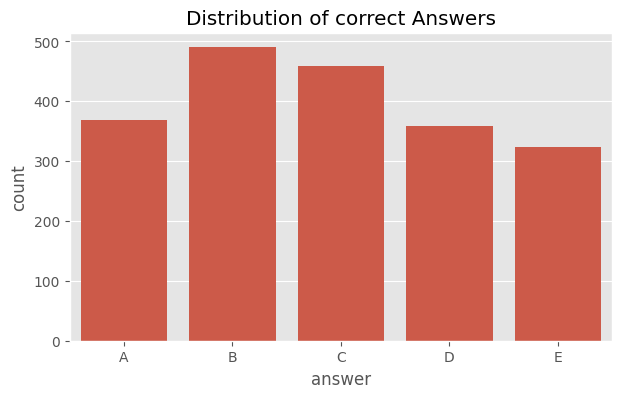

In [132]:
plt.figure(figsize=(7,4))

sns.countplot(data=train,x="answer",order=sorted(train.answer.unique()))

plt.title("Distribution of correct Answers")

plt.show()

# Distribution of Prompt Lengths

The histogram illustrates the distribution of prompt lengths (measured in characters) across the training dataset.

#### Observations
- Most prompts contain **approximately 500–1400 characters**, indicating that the majority of questions are of moderate length.
- The distribution is **right-skewed**, with a small number of very long prompts extending beyond 2000 characters.
- The smooth density curve (KDE) shows that the highest concentration of prompts lies between **600 and 1300 characters**.
- Very short and extremely long prompts are relatively uncommon compared to the majority of the dataset.
- The variation in prompt length suggests that the dataset contains questions of different complexity and detail, making it suitable for evaluating both traditional machine learning models and transformer-based models.

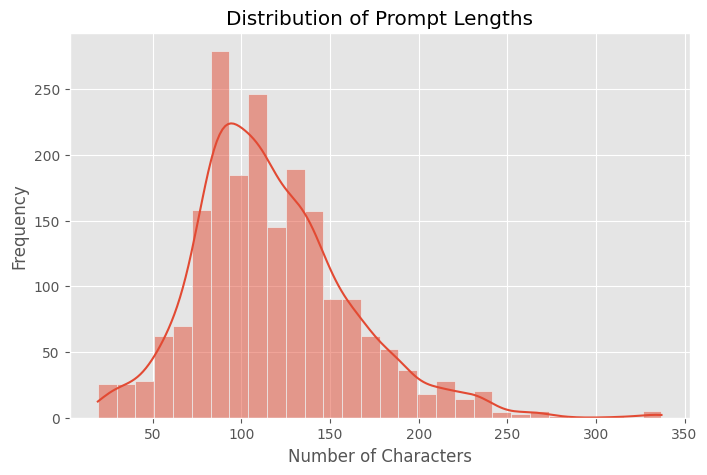

In [133]:
train["prompt_length"] = train["prompt"].str.len()

plt.figure(figsize=(8,5))

sns.histplot(train["prompt_length"], bins=30, kde=True)

plt.title("Distribution of Prompt Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

# Authentication Setup

This section authenticates the notebook with Hugging Face and Weights & Biases (W&B) using API keys stored securely in Kaggle Secrets.

**Observation:**

- Authentication is performed securely without exposing API keys.
- Hugging Face access enables downloading pretrained models.
- W&B authentication enables experiment tracking and logging.
- The displayed W&B warnings are informational and do not affect execution.

In [134]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

login(hf_token)

In [135]:
import wandb

user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_api)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

# Data Cleaning

This section performs basic text preprocessing by removing extra whitespace and trimming leading and trailing spaces from each question prompt.

**Observation:**

- Multiple spaces are replaced with a single space.
- Leading and trailing whitespace is removed from each prompt.
- The same cleaning process is applied to both the training and test datasets.
- This preprocessing improves text consistency before tokenization and model training.

In [136]:
import re
import string

In [137]:
def clean_data(text):
  text = re.sub(r"\s+"," ",text)
  return text.strip()

train['prompt'] = train['prompt'].apply(clean_data)
test['prompt'] = test['prompt'].apply(clean_data)

# Label Encoding

This section converts the target labels (**A–E**) into numerical values required for model training and creates a reverse mapping to decode predictions.

**Observation:**

- Answer labels are encoded from **A–E** to **0–4**.
- A reverse mapping is created to convert predictions back to their original labels.
- Numerical encoding enables efficient training of the deep learning model.
- The encoded labels are stored in a new `label` column without modifying the original answers.

In [138]:
label2id = {
    "A" : 0 ,
    "B" : 1 ,
    "C" : 2 ,
    "D" : 3 ,
    "E" : 4
}

id2label = {
   0  : "A" ,
   1  : "B" ,
   2  : "C" ,
   3  : "D" ,
   4  : "E" 
}


train['label'] = train['answer'].map(label2id)

# Input Formatting

This section combines each question and its five answer choices into a single formatted text sequence for transformer-based model training.

**Observation:**

- Each input contains the question followed by options **A–E**.
- A consistent text format is used for both the training and test datasets.
- Combining the prompt and options provides the model with complete context for answer prediction.

In [139]:
def create_input(example):
  return (
      f"Question: {example['prompt']}"
      f"A: {example['A']}"
      f"B: {example['B']}"
      f"C: {example['C']}"
      f"D: {example['D']}"
      f"E: {example['E']}"
  )
train['text'] = train.apply(create_input,axis=1)
test['text'] = test.apply(create_input,axis=1)

# Train–Validation Split

This section splits the training data into training and validation sets for model evaluation while preserving the class distribution.

**Observation:**

- The dataset is split into **75% training** and **25% validation**.
- Stratified sampling maintains the original class distribution in both sets.
- A fixed random seed (`random_state=42`) ensures reproducible results.

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    train["text"],
    train["label"],
    test_size=0.25,
    stratify=train["label"],
    random_state=42
)

In [141]:
print(f"X train shape {X_train.shape}")
print(f"Y train shape {y_train.shape}")
print(f"X valid shape {X_valid.shape}")
print(f"Y valid shape {y_valid.shape}")

X train shape (1500,)
Y train shape (1500,)
X valid shape (500,)
Y valid shape (500,)


# Tf-Idf Vecrtoizer


In [142]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_vect = vectorizer.fit_transform(X_train).toarray()
X_valid_vect = vectorizer.transform(X_valid).toarray()
X_test_vect = vectorizer.transform(test["text"]).toarray()

# Converting to Pytorch Tensors

In [143]:
import torch

X_train_tensor = torch.tensor(X_train_vect, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_vect, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_vect, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_valid_tensor = torch.tensor(y_valid.to_numpy(), dtype=torch.long)

## Custom PyTorch Dataset

A custom `TextDataset` class was created by inheriting from PyTorch's `Dataset` class to efficiently manage the training and testing data.

### Purpose
The custom dataset acts as an interface between the processed data and the PyTorch `DataLoader`. It enables the model to access one sample at a time while allowing the `DataLoader` to automatically create mini-batches during training.

### Implementation Details
- The `__init__()` method stores the input features (`X`) and labels (`y`).
- The `__len__()` method returns the total number of samples in the dataset.
- The `__getitem__()` method retrieves a single input sample and its corresponding label using the provided index.
- For the test dataset, where labels are unavailable, the method returns only the input features.

### Advantages
- Efficient loading of data during training.
- Compatible with PyTorch's `DataLoader` for mini-batch training.
- Supports data shuffling to improve model generalization.
- Reusable for both training/validation datasets and the unlabeled test dataset.

In [144]:
from torch.utils.data import Dataset

class TextDataset(Dataset):

    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

# Create Dataset and DataLoader

In [145]:
import torch
from torch.utils.data import  DataLoader

train_dataset = TextDataset(X_train_tensor, y_train_tensor)
valid_dataset = TextDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TextDataset(X_test_tensor)   # <-- Use X_test_tensor

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Device Configuration

This section selects the available hardware for model training.

**Observation:**

- CUDA is available and selected as the training device.
- GPU acceleration enables faster model training and inference.

In [146]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)

cpu


# ANN

In [147]:
import torch.nn as nn

class ANNClassifier(nn.Module):

    def __init__(self, input_dim, num_classes):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)

        )

    def forward(self, x):
        return self.model(x)

# Loss Function & Optimizer and Model Initializing

This section defines the loss function and optimizer used during training.

**Observation:**

- Cross-Entropy Loss is used for multi-class classification.
- The Adam optimizer updates model parameters efficiently.

In [148]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ANNClassifier(
    X_train_tensor.shape[1],
    len(torch.unique(y_train_tensor))
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# Weights & Biases Setup

This section initializes Weights & Biases (W&B) for experiment tracking.

**Observation:**

- Model configuration and hyperparameters are logged.
- Training metrics are tracked throughout the experiment.
- Results can be monitored and compared easily.

In [149]:
wandb.init(
    project="DL-GenAI-2026-T2",
    name="ANN",
    config={
        "model": "Artificial Neural Network (ANN)",
        "feature_extraction": "TF-IDF",
        "max_features": 50000,
        "ngram_range": (1, 2),
        "input_dim": X_train_tensor.shape[1],
        "hidden_layers": [512, 256, 128],
        "activation": "ReLU",
        "dropout": 0.3,
        "output_classes": len(torch.unique(y_train_tensor)),
        "batch_size": 64,
        "epochs": 10,
        "learning_rate": 0.01,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss"
    }
)

# Training

In [150]:
EPOCHS = 10

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # =======================
    # Training
    # =======================
    model.train()

    total_train_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)

    # =======================
    # Validation
    # =======================
    model.eval()

    total_valid_loss = 0

    with torch.no_grad():

        for inputs, labels in valid_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            total_valid_loss += loss.item()

    valid_loss = total_valid_loss / len(valid_loader)

    # wandb.log({
    # "Train Loss": train_loss,
    # "Validation Loss": valid_loss
    # })

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {valid_loss:.4f}")


Epoch 1/10
Train Loss      : 0.7963
Validation Loss : 0.0601

Epoch 2/10
Train Loss      : 0.1016
Validation Loss : 0.0289

Epoch 3/10
Train Loss      : 0.0421
Validation Loss : 0.0000

Epoch 4/10
Train Loss      : 0.0363
Validation Loss : 0.0000

Epoch 5/10
Train Loss      : 0.0000
Validation Loss : 0.0000

Epoch 6/10
Train Loss      : 0.0388
Validation Loss : 0.0000

Epoch 7/10
Train Loss      : 0.0066
Validation Loss : 0.0000

Epoch 8/10
Train Loss      : 0.0190
Validation Loss : 0.0000

Epoch 9/10
Train Loss      : 0.0572
Validation Loss : 0.0872

Epoch 10/10
Train Loss      : 0.0341
Validation Loss : 0.0000


In [151]:
torch.save(model.state_dict(), "best_ann.pt")

state = torch.load("best_ann.pt", map_location="cpu")
print(list(state.keys())[:10])

['model.0.weight', 'model.0.bias', 'model.3.weight', 'model.3.bias', 'model.6.weight', 'model.6.bias', 'model.9.weight', 'model.9.bias']


# Saving the model 

In [152]:
# wandb.finish()

torch.save(model.state_dict(), "ann.pth")
print("Model saved successfully!")

Model saved successfully!


# Prediction

In [153]:
top3_predictions = []

with torch.no_grad():

    for inputs in test_loader:

        inputs = inputs.float().to(device)

        outputs = model(inputs)

        top3 = torch.topk(outputs, k=3, dim=1).indices

        top3_predictions.extend(top3.cpu().numpy())

In [154]:
pred_labels_lstm = []

for row in top3_predictions:

    pred_labels_lstm.append(" ".join(id2label[i] for i in row))

# Generate Final Predictions

This section converts the predicted class indices into their corresponding answer labels for submission.

**Observation:**

- Predicted class indices are mapped back to labels **A–E**.
- The top three predictions are combined into the required submission format.
- A total of **500 predictions** are generated, matching the test dataset size.

# MODEL - 2

# Distibert-base-uncased

In [155]:
from transformers import AutoTokenizer , AutoModelForSequenceClassification
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


# Tokenizer

In [156]:
MAX_LEN = 256

train_enc = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
    return_tensors="pt"
)

valid_enc = tokenizer(
    X_valid.tolist(),
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
    return_tensors="pt"
)

test_enc = tokenizer(
    test["text"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
    return_tensors="pt"
)

# TensorDataset

In [157]:
class TextDataset(Dataset):

    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):

        item = {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx]
        }

        if self.labels is not None:
            item["labels"] = self.labels[idx]

        return item

# DataLoader

In [158]:
from torch.utils.data import DataLoader


train_dataset = TextDataset(X_train, y_train)
valid_dataset = TextDataset(X_valid, y_valid)
test_dataset = TextDataset(X_test)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

NameError: name 'X_test' is not defined

# Optmizer

In [ ]:
from torch.optim import AdamW

optimizer = Adam(
    model.parameters(),
    lr=1e-5
)

# Training

In [ ]:
from tqdm.auto import tqdm

model.train()

train_loss = 0

train_bar = tqdm(train_loader, desc="Training")

for batch in train_bar:

    input_ids = batch[0].to(device)
    attention_mask = batch[1].to(device)
    labels = batch[2].to(device)

    optimizer.zero_grad()

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss

    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    train_loss += loss.item()

    train_bar.set_postfix(loss=f"{loss.item():.4f}")

train_loss /= len(train_loader)

print(f"Training Loss : {train_loss:.4f}")

# Validation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()

val_loss = 0

predictions = []
targets = []

with torch.no_grad():

    val_bar = tqdm(valid_loader, desc="Validation")

    for batch in val_bar:

        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        val_loss += outputs.loss.item()

        preds = torch.argmax(outputs.logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.cpu().numpy())

val_loss /= len(valid_loader)

val_acc = accuracy_score(targets, predictions)
val_f1 = f1_score(targets, predictions, average="macro")

print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Validation Macro F1 : {val_f1:.4f}")

# Save Best Model Cell

In [ ]:
if val_f1 > best_f1:
    best_f1 = val_f1

    torch.save(model, "best_distilbert.pt")   # Save the complete model

    print("Best model saved!")

# Load Best Model

In [ ]:
from tqdm.auto import tqdm

model.eval()

top3_predictions = []

with torch.no_grad():

    test_bar = tqdm(test_loader, desc="Predicting")

    for batch in test_bar:

        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        top3 = torch.topk(
            outputs.logits,
            k=3,
            dim=1
        ).indices

        top3_predictions.extend(top3.cpu().numpy())

# Converting Predictions

In [ ]:
predictions = []

for row in top3_predictions:
    predictions.append(
        " ".join(id2label[i] for i in row)
    )

# Model 3 Clasical ML Model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score


import numpy as np
import pandas as pd
import joblib
import time

start_time = time.time()

tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    max_features=150000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    smooth_idf=True,
    norm="l2",
    stop_words=None
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(test["text"])

# Logistic Regression

In [ ]:
lr_model = LogisticRegression(
    C=4,
    solver="saga",
    penalty="l2",
    max_iter=6000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

#   Validation + Best Ensemble Weight

In [ ]:
lr_prob = lr_model.predict_proba(X_valid_tfidf)
lgb_prob = lgb_model.predict_proba(X_valid_tfidf)

best_f1 = 0
best_weight = 0

for w in np.arange(0.1,1.0,0.05):

    ensemble_prob = w*lr_prob + (1-w)*lgb_prob

    pred = np.argmax(ensemble_prob,axis=1)

    score = f1_score(
        y_valid,
        pred,
        average="macro"
    )

    if score > best_f1:
        best_f1 = score
        best_weight = w

print("="*50)
print("Best LR Weight :",best_weight)
print("Best Macro F1 :",best_f1)
print("="*50)

ensemble_prob = best_weight*lr_prob + (1-best_weight)*lgb_prob

pred = np.argmax(ensemble_prob,axis=1)

acc = accuracy_score(y_valid,pred)

macro_f1 = f1_score(
    y_valid,
    pred,
    average="macro"
)

print("Validation Accuracy :",acc)
print("Validation Macro F1 :",macro_f1)

# W&B

# Save Models

In [ ]:
joblib.dump(tfidf,"tfidf.pkl")
joblib.dump(lr_model,"lr_model.pkl")
joblib.dump(lgb_model,"lgb_model.pkl")

# Test Prediction

In [ ]:
lr_test_prob = lr_model.predict_proba(X_test_tfidf)

lgb_test_prob = lgb_model.predict_proba(X_test_tfidf)

ensemble_prob = (

    best_weight*lr_test_prob +

    (1-best_weight)*lgb_test_prob

)

# Top 3

In [ ]:
top3 = np.argsort(
    ensemble_prob,
    axis=1
)[:, -3:]

top3 = top3[:, ::-1]

predictions = [

    " ".join(

        id2label[i]

        for i in row

    )

    for row in top3

]

# Submission

In [ ]:
submission = sample.copy()

submission["Prediction"] = predictions

submission.head()

## Save Submission

In [ ]:
submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission saved successfully!")